# Index
1. Get the dataset
2. Converting each Record to a graph notation
3. Train Test Loader
4. GNN Definition

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.nn import Linear, ModuleList
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv
from torch_geometric.nn import Set2Set

import wandb

# Monkey-patch: PyTorch 1.12 doesn't support weights_only kwarg
# Guard against re-run: only patch once
# if not hasattr(torch, '_original_load'):
torch._original_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs.pop('weights_only', None)
    return torch._original_load(*args, **kwargs)
torch.load = _patched_torch_load


## 1. Get the dataset

The dataset used is `combined_dataset.csv`


In [2]:
# load dataset
DATA_ROOT = './data/models'
RAW_DIR  = os.path.join(DATA_ROOT, 'raw')

df = pd.read_csv(os.path.join(RAW_DIR, 'combined_dataset.csv'), index_col="SEQID")

df.sort_index(inplace=True)

with open(os.path.join(RAW_DIR, 'combined_data_split.json'), 'r') as f:
    split_dict = json.load(f)

print(f"Total records: {len(df)}")
print(df['dataset'].value_counts())
df.head()


Total records: 30872
arr       27730
ov         2775
lit_uv      348
uv           19
Name: dataset, dtype: int64


,dataset,RefSeq,TargetStruct,sodium,DNA_conc,dH,Tm,dG_37
SEQID,,,,,,,,
BC1,arr,CAACCAGAAATGGTTG,((((((....)))))),0.063,NaN,-29.405457,52.382626,-1.389517
BC10,arr,CAATCAGAAATGGTTG,(((.((....)).))),0.063,NaN,-13.860604,28.607763,0.385480
BC11,arr,CAAGCAGAAATGGTTG,(((.((....)).))),0.063,NaN,-19.310492,32.871813,0.260496
BC15,arr,AGAAACCGAAAGGCTTCT,((((.((....)).)))),0.063,NaN,-28.359914,40.193048,-0.288995
BC16,arr,AGAATCCGAAAGGCTTCT,((((.((....)).)))),0.063,NaN,-27.266132,34.866015,0.188904


## 2. Converting each Record to a graph notation

In the dataset we have below two parameters for each sequence-
1. RefSeq e.g. `ATGCGCTA`
2. TargetStruct e.g. `(((....)))`

The above two are parameters for representing the sequence/dna hairpin in a graph format.


Now a graph has:
1. Nodes : one node for each nucleotide i.e. `A`, `T`, `G` and `C`
2. Edges : There are 3 types of edges.
    1. $5'-3'$ edge representing a froward link
    2. $3'-5'$ edge representing a backward link
    3. hydrogen bond <br>
    
The bond `1` and `2` are classified as backbone bond.<br>`.` in the `TargetStruct` represent a hydrogen bond. 


In [3]:
# ---- Feature encoding functions ----

def onehot_nucleotide(seq_str: str) -> np.ndarray:
    """One-hot encode a DNA sequence. Returns (N, 4) array."""
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}
    N = len(seq_str)
    arr = np.zeros((N, 4), dtype=np.float32)
    for i, nt in enumerate(seq_str.upper()):
        arr[i, mapping[nt]] = 1.0
    return arr


def dotbracket_to_edges(struct: str):
    """
    Convert dot-bracket notation to edge list + edge features.
    
    Returns:
        edge_index: (2, num_edges) tensor
        edge_attr: (num_edges, 3) tensor - [is_5to3, is_3to5, is_hbond]
    """
    N = len(struct)
    strand_break = struct.find('+')
    
    if strand_break == -1:
        # Hairpin: backbone connects all consecutive nucleotides
        backbone = [[i, i+1] for i in range(N - 1)]
    else:
        # Duplex: remove '+' and skip the break position
        struct = struct.replace('+', '')
        N -= 1
        backbone = [[i, i+1] for i in range(N - 1)
                    if i != strand_break - 1 and i + 1 != strand_break]
    
    # Find hydrogen bonds from matched parentheses
    hbonds = []
    flag3p = N - 1
    for i, ch in enumerate(struct):
        if ch == '(':
            for j in range(flag3p, i, -1):
                if struct[j] == ')':
                    hbonds.append([i, j])
                    flag3p = j - 1
                    break
    
    # Build full edge list: 5'→3', 3'→5', hbond (both directions)
    print(f"Backbone {backbone}\nBackbone reversed {[e[::-1] for e in backbone]}\nHbond {hbonds}\nHbonds rev {[e[::-1] for e in hbonds]}")
    print(f"shape of each\nBackbone {torch.tensor(backbone).shape}\nHbond {torch.tensor(hbonds).shape}")
    edges = (backbone + 
             [e[::-1] for e in backbone] + 
             hbonds + 
             [e[::-1] for e in hbonds])
    

    print(edges)
    print(f"Shape of edges is {torch.tensor(edges).shape}")
    n_bb, n_hb = len(backbone), len(hbonds)
    edge_attr = np.zeros((len(edges), 3), dtype=np.float32)
    edge_attr[:n_bb, 0] = 1           # 5' → 3'
    edge_attr[n_bb:2*n_bb, 1] = 1     # 3' → 5'
    edge_attr[2*n_bb:, 2] = 1         # hydrogen bonds
    
    edge_index = torch.tensor(np.array(edges).T, dtype=torch.long)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    return edge_index, edge_attr


# Quick sanity check
ei, ea = dotbracket_to_edges('((..))')
print(f'Structure "((..))": {ei.shape[1]} edges, {ea.shape}')
print(f'One-hot "ATCG":\n{onehot_nucleotide("ATCGATGC")}')

Backbone [[0, 1], [1, 2], [2, 3], [3, 4], [4, 5]]
Backbone reversed [[1, 0], [2, 1], [3, 2], [4, 3], [5, 4]]
Hbond [[0, 5], [1, 4]]
Hbonds rev [[5, 0], [4, 1]]
shape of each
Backbone torch.Size([5, 2])
Hbond torch.Size([2, 2])
[[0, 1], [1, 2], [2, 3], [3, 4], [4, 5], [1, 0], [2, 1], [3, 2], [4, 3], [5, 4], [0, 5], [1, 4], [5, 0], [4, 1]]
Shape of edges is torch.Size([14, 2])
Structure "((..))": 14 edges, torch.Size([14, 3])
One-hot "ATCG":
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]


In [4]:
def calc_sumstats(df):
    """Compute min/max for dH and Tm from a dataframe. """
    """this function assums the input does not have NO nan values. """
    return {
        'dH_min' : np.min(df.dH), 'dH_max': np.max(df.dH),
        'Tm_min': np.min(df.Tm), 'Tm_max': np.max(df.Tm)
    } 

def normalize(val, vmin, vmax):
    return (val - vmin) / (vmax - vmin)

def unnormalize(val, vmin, vmax):
    return val * (vmax - vmin) + vmin

train_df = df.loc[df.index.isin(split_dict['train_ind'])]

stats = calc_sumstats(train_df)
print('Training set normalization stats:')
stats

Training set normalization stats:


{'dH_min': -68.20454632608892,
 'dH_max': -2.70243642577065,
 'Tm_min': 13.647488646379209,
 'Tm_max': 68.63588396988382}

In [5]:
def row_to_graph(row, stats):
    """
    Converts a single dataframe row into troch_geometric Data object.mro
    Args:
        row: pandas Series with RefSeq, TargetStruct, dH, Tm
        stats: dict with min and max for dH and Tm
    Returns:
        Data(x, edge_inded, edge_attr, y)
    """
    # Parse RefSeq (handle string-repr lists for duplex)
    reference_sequence = row['RefSeq']
    if isinstance(reference_sequence, list):
        reference_sequence = ''.join(reference_sequence)
    elif isinstance(reference_sequence, str) and '[' in reference_sequence:
        reference_sequence = ''.join(eval(reference_sequence))

    # Node features: one-hot nucleotides
    x = torch.tensor(onehot_nucleotide(reference_sequence), dtype=torch.float)

    # Edge features: from dot-bracket structure
    edge_index, edge_attr = dotbracket_to_edges(row['TargetStruct'])

    # Normalize the labels

    dH_norm = normalize(row.dH, stats['dH_min'], stats['dH_max'])
    Tm_norm = normalize(row.Tm, stats['Tm_min'], stats['Tm_max'])
    y = torch.tensor([dH_norm, Tm_norm], dtype=torch.float)

    return Data(x = x, edge_index=edge_index, edge_attr=edge_attr, y=y)

sample = df.iloc[0]
g = row_to_graph(sample, stats)
print(f"Sample graph: {g.num_nodes} nodes, {g.num_edges} edges, y={g.y}")

Backbone [[0, 1], [1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 8], [8, 9], [9, 10], [10, 11], [11, 12], [12, 13], [13, 14], [14, 15]]
Backbone reversed [[1, 0], [2, 1], [3, 2], [4, 3], [5, 4], [6, 5], [7, 6], [8, 7], [9, 8], [10, 9], [11, 10], [12, 11], [13, 12], [14, 13], [15, 14]]
Hbond [[0, 15], [1, 14], [2, 13], [3, 12], [4, 11], [5, 10]]
Hbonds rev [[15, 0], [14, 1], [13, 2], [12, 3], [11, 4], [10, 5]]
shape of each
Backbone torch.Size([15, 2])
Hbond torch.Size([6, 2])
[[0, 1], [1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 8], [8, 9], [9, 10], [10, 11], [11, 12], [12, 13], [13, 14], [14, 15], [1, 0], [2, 1], [3, 2], [4, 3], [5, 4], [6, 5], [7, 6], [8, 7], [9, 8], [10, 9], [11, 10], [12, 11], [13, 12], [14, 13], [15, 14], [0, 15], [1, 14], [2, 13], [3, 12], [4, 11], [5, 10], [15, 0], [14, 1], [13, 2], [12, 3], [11, 4], [10, 5]]
Shape of edges is torch.Size([42, 2])
Sample graph: 16 nodes, 42 edges, y=tensor([0.5923, 0.7044])


In [6]:
class NNNGraphDataset(InMemoryDataset):
    """
    Converts combined_dataset.csv into graph dataset
    Processes once, then loads from disk.
    """

    def __init__(self, root, transform=None):
        
        super().__init__(root, transform)
        self.data, self.slices = torch.load(self.processed_paths[0])

        # Load metadata
        self.df = pd.read_csv(os.path.join(self.raw_dir, 'combined_dataset.csv'), index_col = 'SEQID')
        self.df.sort_index(inplace=True)

        # BUG FIX 1: was 'combined_dataset.csv' (CSV, not JSON!)
        with open(os.path.join(self.raw_dir, 'combined_data_split.json')) as f:
            self.split_dict = json.load(f)

        self.stats = calc_sumstats(self.df.loc[self.df.index.isin(self.split_dict['train_ind'])])
    
    @property
    def raw_file_names(self):
        return['combined_dataset.csv', 'combined_data_split.json']
    
    @property
    def processed_file_names(self):
        return ['my_gnn_data.pt']

    def process(self):
        """Convert each record in csv to a graph format and then save"""

        print("Processing dataset ")
        df = pd.read_csv(os.path.join(self.raw_dir, 'combined_dataset.csv'), index_col='SEQID')
        df.sort_index(inplace=True)

        with open(os.path.join(self.raw_dir, 'combined_data_split.json')) as f:
            split_dict = json.load(f)

        train_stats = calc_sumstats(df.loc[df.index.isin(split_dict['train_ind'])])

        data_list = []
        for _, row in df.iterrows():
            data_list.append(row_to_graph(row, train_stats))
        
        data, slices = self.collate(data_list)

        
        torch.save((data, slices), self.processed_paths[0])

        print(f"Saved {len(data_list)} graphs")

    def get_split(self, split='train', dataset_name='arr'):
        """get indices for a specific split and dataset subset"""
        
        seqids = self.df.index
        split_ids = self.split_dict[split + '_ind']
        split_positions = np.searchsorted(seqids, split_ids)

        if dataset_name is not None:
            dataset_mask = (self.df['dataset'] == dataset_name).values
            dataset_positions = set(np.where(dataset_mask)[0])
            positions = sorted(set(split_positions) & dataset_positions)
        else:
            positions = sorted(split_positions)

        return self.index_select(positions)


# Build dataset
dataset = NNNGraphDataset(root=DATA_ROOT)

print(f'Total graphs: {len(dataset)}')
print(f'Stats: {dataset.stats}')

Total graphs: 30872
Stats: {'dH_min': -68.20454632608892, 'dH_max': -2.70243642577065, 'Tm_min': 13.647488646379209, 'Tm_max': 68.63588396988382}


## 3. Create Train Test Loader

In [7]:
BATCH_SIZE = 1842

has_gpu = torch.cuda.is_available()

train_data = dataset.get_split('train', 'arr')
val_data  = dataset.get_split('val', 'arr')
test_data = dataset.get_split('test', 
                              'arr')

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=has_gpu)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=has_gpu)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=has_gpu)

print(f"Train: {len(train_data)} graphs, {len(train_loader)} batches")
print(f"Val: {len(val_data)} graphs, {len(val_loader)} batches")
print(f"Test: {len(test_data)} graphs, {len(test_loader)} batches")

Train: 25025 graphs, 14 batches
Val: 1318 graphs, 1 batches
Test: 1387 graphs, 1 batches


## 4. GNN Definition

In [8]:
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels = 125, n_conv_layers=4,
                 linear_hidden=128, conv_dropout=0.0127,
                 linear_dropout=0.25, set2set_steps=10):
        
        super().__init__()
        torch.manual_seed(12345)

        self.conv_dropout = conv_dropout
        self.linear_dropout = linear_dropout

        # Layer 1
        self.convs = ModuleList()
        self.convs.append(
            TransformerConv(4, hidden_channels, heads=1,
                            edge_dim=3, dropout=conv_dropout)
        )

        # Layer 2, 3, 4 
        for _ in range(n_conv_layers -1):
            self.convs.append(
                TransformerConv(hidden_channels, hidden_channels, heads=1,
                                edge_dim=3, dropout=conv_dropout)
            )

        # Pooling: set2set
        self.pool = Set2Set(hidden_channels, processing_steps=set2set_steps)


        self.lin1 = Linear(2 * hidden_channels, linear_hidden)
        self.lin2 = Linear(linear_hidden, linear_hidden)
        self.lin3 = Linear(linear_hidden, 2)

    def forward(self, x, edge_index, edge_attr, batch):
        
        # 1. Graph Convolutional layers
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)

            x = F.leaky_relu(x)
            x = F.dropout(x, p=self.conv_dropout, training=self.training)
        
        # 2. Pooling layer
        x = self.pool(x, batch)

        # 3. MLP prediction head
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.linear_dropout, training=self.training)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)

        return torch.flatten(x)

model = GNN().to(device='cuda:0')
n_params = sum(p.numel() for p in model.parameters())

print(f"Model has {n_params:,} parameters")
print(model)

Model has 430,398 parameters
GNN(
  (convs): ModuleList(
    (0): TransformerConv(4, 125, heads=1)
    (1): TransformerConv(125, 125, heads=1)
    (2): TransformerConv(125, 125, heads=1)
    (3): TransformerConv(125, 125, heads=1)
  )
  (pool): Set2Set(125, 250)
  (lin1): Linear(in_features=250, out_features=128, bias=True)
  (lin2): Linear(in_features=128, out_features=128, bias=True)
  (lin3): Linear(in_features=128, out_features=2, bias=True)
)


### 4.1 Evaluation Metrics

In [10]:
device = torch.device('cuda:0' if torch.cuda.is_available else 'cpu')

In [11]:
@torch.no_grad()
def compute_rmse(model, loader):
    model.eval()
    total_se = 0.0
    n = len(loader.dataset)
    
    for data in loader:
        out = model(data.x.to(device), data.edge_index.to(device),
                    data.edge_attr.to(device), data.batch.to(device))
        
        total_se += float(((out - data.y.to(device)) ** 2).sum())
    
    
    return np.sqrt(total_se/n)

## 5. Hyperparameter $\text{DEF}^n$

In [15]:
CONFIG = dict(
    n_epoch = 200,
    learning_rate = 0.002379,
    batch_size = BATCH_SIZE,
    hidden_channels = 125,
    n_conv_layers = 4,
    linear_hidden = 4,
    conv_dropout=0.0127,
    linear_dropout=0.25,
    set2set_steps=10,
    architecture='GraphTransformer',
    dataset='NNN_v2'
)


run = wandb.init(project='NNN_GNN', config=CONFIG)
print(f'wandb run: {run.name}')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/anant/.netrc.
wandb: Currently logged in as: apati087 (apati087-university-of-california-riverside) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb run: flowing-sun-16


### 5.1 Training Loop

In [16]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
history = {'epoch': [], 'train_rmse': [], 'val_rmse': []}

LOG_EVERY = 10 # EVALUATE EVERY 10 EPOCHS

for epoch in range(CONFIG['n_epoch']):

    model.train()

    for data in train_loader:
        
        # Forward Pass
        out = model(data.x.to(device), data.edge_index.to(device), 
                    data.edge_attr.to(device), data.batch.to(device))
        
        # Compute loss
        loss = criterion(out, data.y.to(device))

        # Backward Pass + optimize
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    # ---------- Evaluate every Log_every epoch ----------
    if epoch % LOG_EVERY == 0:
        train_rmse = compute_rmse(model, train_loader)
        val_rmse = compute_rmse(model, val_loader)

        history['epoch'].append(epoch)
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)

        wandb.log({'train_rmse': train_rmse, 'val_rmse': val_rmse}, step=epoch)
        print(f"Epoch {epoch:03d} | Train Rmse: {train_rmse:.4f} | Val Rmse {val_rmse:.4f}")


print('\nTraining Done!!')



Epoch 000 | Train Rmse: 0.2804 | Val Rmse 0.2802
Epoch 010 | Train Rmse: 0.2337 | Val Rmse 0.2352
Epoch 020 | Train Rmse: 0.1643 | Val Rmse 0.1678
Epoch 030 | Train Rmse: 0.1454 | Val Rmse 0.1494
Epoch 040 | Train Rmse: 0.1373 | Val Rmse 0.1418
Epoch 050 | Train Rmse: 0.1158 | Val Rmse 0.1204
Epoch 060 | Train Rmse: 0.1177 | Val Rmse 0.1229
Epoch 070 | Train Rmse: 0.1120 | Val Rmse 0.1177
Epoch 080 | Train Rmse: 0.1103 | Val Rmse 0.1167
Epoch 090 | Train Rmse: 0.1073 | Val Rmse 0.1146
Epoch 100 | Train Rmse: 0.1067 | Val Rmse 0.1147
Epoch 110 | Train Rmse: 0.1031 | Val Rmse 0.1115
Epoch 120 | Train Rmse: 0.1031 | Val Rmse 0.1124
Epoch 130 | Train Rmse: 0.1080 | Val Rmse 0.1166
Epoch 140 | Train Rmse: 0.1015 | Val Rmse 0.1117
Epoch 150 | Train Rmse: 0.1072 | Val Rmse 0.1171
Epoch 160 | Train Rmse: 0.1015 | Val Rmse 0.1122
Epoch 170 | Train Rmse: 0.1065 | Val Rmse 0.1161
Epoch 180 | Train Rmse: 0.1061 | Val Rmse 0.1163
Epoch 190 | Train Rmse: 0.0987 | Val Rmse 0.1098

Training Done!!


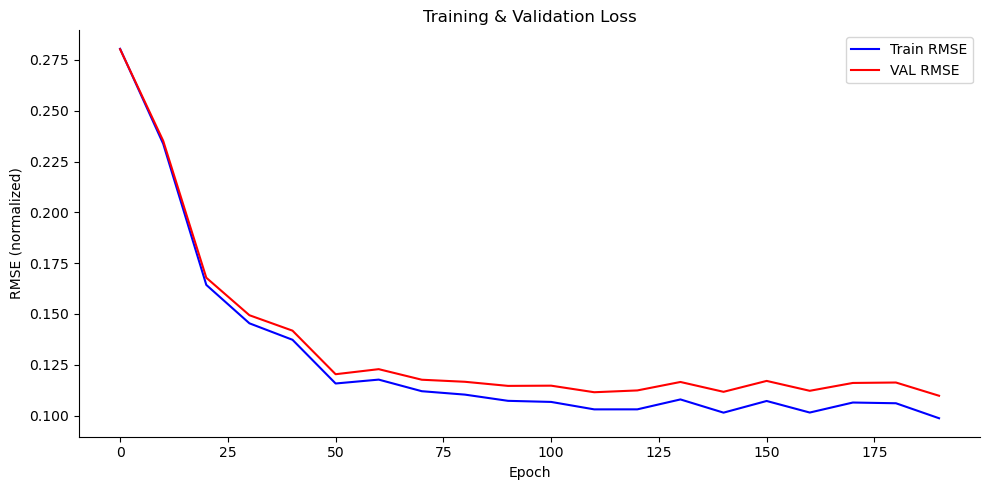

In [19]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot(history['epoch'], history['train_rmse'], label='Train RMSE' , color="blue")
ax.plot(history['epoch'], history['val_rmse'], label='VAL RMSE' , color="red")
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE (normalized)')
ax.set_title('Training & Validation Loss')
ax.legend()
sns.despine()
plt.tight_layout()
wandb.log({'loss_curves': wandb.Image(fig)})
plt.show()

## 5. Unnormalize the predictions for Evaluation and Results

In [ ]:


@torch.no_grad()
def get_predictions(model, loader, stats):
    """Run model on a loader and return truth/pred arrays in original scale."""
    model.eval()
    y_all, pred_all = [], []
    
    for data in loader:
        out = model(data.x.to(device), data.edge_index.to(device),
                    data.edge_attr.to(device), data.batch.to(device))
        y_all.append(data.y.numpy().reshape(-1, 2))
        pred_all.append(out.cpu().numpy().reshape(-1, 2))
    
    y = np.concatenate(y_all)
    pred = np.concatenate(pred_all)
    
    # Unnormalize
    y[:, 0] = unnormalize(y[:, 0], stats['dH_min'], stats['dH_max'])
    y[:, 1] = unnormalize(y[:, 1], stats['Tm_min'], stats['Tm_max'])
    pred[:, 0] = unnormalize(pred[:, 0], stats['dH_min'], stats['dH_max'])
    pred[:, 1] = unnormalize(pred[:, 1], stats['Tm_min'], stats['Tm_max'])
    
    return y, pred


def calc_dG37(dH, Tm):
    """Calculate dG at 37°C from dH (kcal/mol) and Tm (°C)."""
    return dH * (1 - (273.15 + 37) / (273.15 + Tm))


train_y, train_pred = get_predictions(model, train_loader, dataset.stats)
val_y, val_pred = get_predictions(model, val_loader, dataset.stats)

## 6. Results

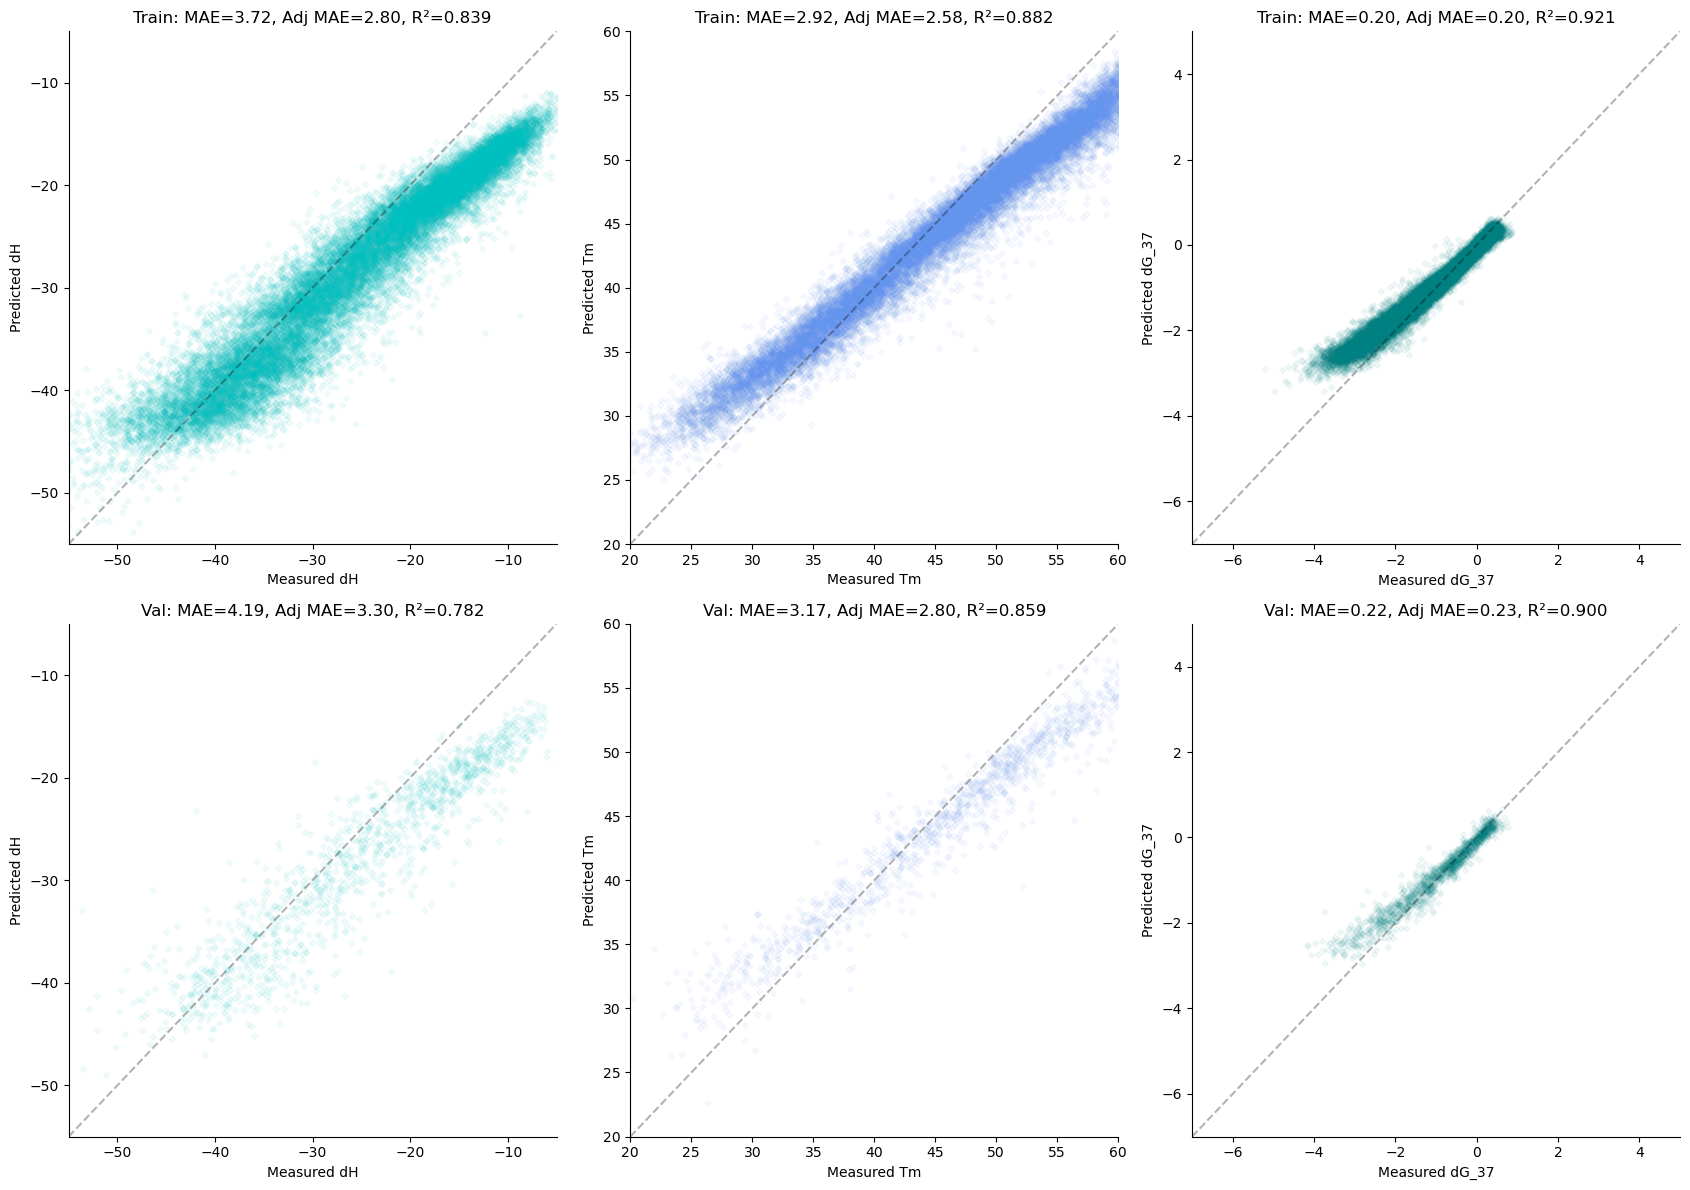


                     Validation Results                     
Metric            MAE    Adj MAE     RMSE       R²     Bias
------------------------------------------------------------
dH             4.1853     3.2993   5.1439   0.7824  -2.7872
Tm             3.1733     2.8013   4.0607   0.8589  -1.7465
dG_37          0.2239     0.2268   0.3270   0.8998   0.1111


In [24]:
# ---- Truth vs Predicted scatter plots ----
from sklearn.metrics import r2_score

def plot_scatter(y, pred, ax, param_name, title, color, lim):
    """Plot measured vs predicted scatter with MAE, Adjusted MAE, R²."""
    mask = ~np.isnan(y)
    y, pred = y[mask], pred[mask]
    
    rmse = np.sqrt(np.mean((y - pred)**2))
    mae = np.mean(np.abs(y - pred))
    r2 = r2_score(y, pred)
    
    # Adjusted MAE: remove mean bias, then compute MAE
    bias = np.mean(pred) - np.mean(y)
    pred_adj = pred - bias
    mae_adj = np.mean(np.abs(y - pred_adj))
    
    ax.scatter(y, pred, c=color, marker='D', alpha=0.05, s=10)
    ax.plot(lim, lim, 'k--', alpha=0.3)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'Measured {param_name}')
    ax.set_ylabel(f'Predicted {param_name}')
    ax.set_title(f'{title}: MAE={mae:.2f}, Adj MAE={mae_adj:.2f}, R²={r2:.3f}')
    return dict(rmse=rmse, mae=mae, mae_adj=mae_adj, r2=r2, bias=bias)


fig, axes = plt.subplots(2, 3, figsize=(17, 12))

# Train plots
plot_scatter(train_y[:, 0], train_pred[:, 0], axes[0, 0], 'dH', 'Train', 'c', [-55, -5])
plot_scatter(train_y[:, 1], train_pred[:, 1], axes[0, 1], 'Tm', 'Train', 'cornflowerblue', [20, 60])
train_dG = calc_dG37(train_y[:, 0], train_y[:, 1])
train_dG_pred = calc_dG37(train_pred[:, 0], train_pred[:, 1])
plot_scatter(train_dG, train_dG_pred, axes[0, 2], 'dG_37', 'Train', 'teal', [-7, 5])

# Validation plots
dH_metrics = plot_scatter(val_y[:, 0], val_pred[:, 0], axes[1, 0], 'dH', 'Val', 'c', [-55, -5])
Tm_metrics = plot_scatter(val_y[:, 1], val_pred[:, 1], axes[1, 1], 'Tm', 'Val', 'cornflowerblue', [20, 60])
val_dG = calc_dG37(val_y[:, 0], val_y[:, 1])
val_dG_pred = calc_dG37(val_pred[:, 0], val_pred[:, 1])
dG_metrics = plot_scatter(val_dG, val_dG_pred, axes[1, 2], 'dG_37', 'Val', 'teal', [-7, 5])

sns.despine()
plt.tight_layout()
wandb.log({'results': wandb.Image(fig)})
plt.show()

# Print all metrics
print(f'\n{"="*60}')
print(f'{"Validation Results":^60}')
print(f'{"="*60}')
print(f'{"Metric":<12} {"MAE":>8} {"Adj MAE":>10} {"RMSE":>8} {"R²":>8} {"Bias":>8}')
print(f'{"-"*60}')
for name, m in [('dH', dH_metrics), ('Tm', Tm_metrics), ('dG_37', dG_metrics)]:
    print(f'{name:<12} {m["mae"]:>8.4f} {m["mae_adj"]:>10.4f} {m["rmse"]:>8.4f} {m["r2"]:>8.4f} {m["bias"]:>8.4f}')
print(f'{"="*60}')

# # Log to wandb
# wandb.run.summary.update({
#     'dH_mae': dH_metrics['mae'], 'dH_mae_adj': dH_metrics['mae_adj'], 'dH_r2': dH_metrics['r2'], 'dH_rmse': dH_metrics['rmse'],
#     'Tm_mae': Tm_metrics['mae'], 'Tm_mae_adj': Tm_metrics['mae_adj'], 'Tm_r2': Tm_metrics['r2'], 'Tm_rmse': Tm_metrics['rmse'],
#     'dG_37_mae': dG_metrics['mae'], 'dG_37_mae_adj': dG_metrics['mae_adj'], 'dG_37_r2': dG_metrics['r2'], 'dG_37_rmse': dG_metrics['rmse'],
#     'n_parameters': n_params,
# })